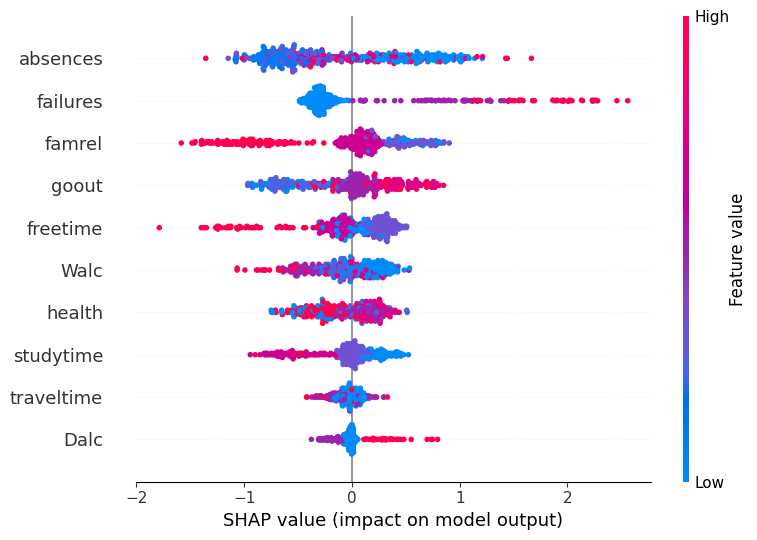

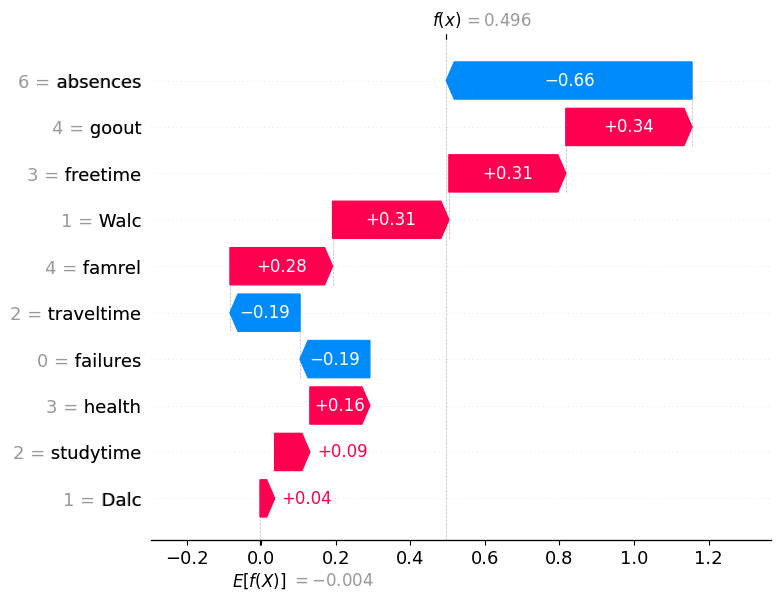

In [1]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

model    = joblib.load('../models/xgb_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')
features = joblib.load('../models/features.pkl')

df = pd.read_csv('../data/student-mat.csv', sep=';')
df['at_risk'] = (df['G3'] < 10).astype(int)

X = scaler.transform(df[features])

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary plot — shows feature importance across all students
shap.summary_plot(shap_values, df[features], show=True)

# Waterfall for one student (index 0)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=df[features].iloc[0],
        feature_names=features
    )
)